In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os, glob, scipy.stats as stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### plot settings

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

In [3]:
df = pd.read_csv('../../results/psychopy/all_subjs_v2.csv')
print(df.shape)
df.head(5)

(2400, 159)


,thisN,thisTrialN,thisRepN,blockN,run,condition,trial_key,stim_file_pos,true_stim,noise_pos,...,stim_boundary_aligned,resp_boundary_aligned,rank_stim,rank_resp,baseline_dur,stim_dur,delay_dur,task_dur,anticipation_dur,feedback_dur
0,39.0,39.0,0.0,5.0,2.0,curv_comp,161.0,0.1,-0.38,1.0,...,-0.18,-0.060,4.5,3.0,0.991922,1.068953,1.342020,2.243022,0.259576,1.150575
1,38.0,38.0,0.0,5.0,2.0,curv_comp,183.0,1.3,-0.14,1.0,...,0.06,0.032,46.5,52.5,1.092014,0.993958,1.391935,2.149563,0.254444,1.027731
2,37.0,37.0,0.0,5.0,2.0,curv_comp,184.0,1.5,-0.10,1.0,...,0.10,0.012,50.5,44.0,0.941931,1.053243,1.441963,1.291744,0.263679,0.992746
3,36.0,36.0,0.0,5.0,2.0,curv_comp,178.0,0.9,-0.22,3.0,...,-0.02,0.024,36.5,47.0,0.941891,1.001235,1.392006,1.655112,0.247250,1.041000
4,35.0,35.0,0.0,5.0,2.0,curv_comp,181.0,1.1,-0.18,1.0,...,0.02,-0.028,42.5,17.0,1.091873,1.006109,1.291994,2.444801,0.248883,1.008979


### picking only newer subjects

In [4]:
# subj_mapping = {'kahini': 1.1, 'renee': 1.11, 'daria': 1.111, 'sienna': 1.1111}

df_subjs = df[df['subj'].isin([1.1, 1.11, 1.111, 1.1111])].copy()
# df_subjs = df[df['subj']==1.1111].copy()

print(df_subjs.shape)
print(df_subjs['subj'].unique())

(960, 159)
[1.1    1.11   1.111  1.1111]


### create valence_condition col with values: pen_comp, baseline, rew_comp

In [5]:
def assign_valence_condition(row):
    if row['condition'] == 'baseline':
        return 'baseline'
    elif (row['blockN'] <= 3 and row['condition'] == 'curv_comp') or (row['blockN'] > 3 and row['condition'] == 'flat_comp'):
        return 'pen_comp'
    else:
        return 'rew_comp'

df_subjs['valence_condition'] = df_subjs.apply(assign_valence_condition, axis=1)
df_subjs['valence_condition'].value_counts()

valence_condition
rew_comp    320
baseline    320
pen_comp    320
Name: count, dtype: int64

### create valence_boundary and valence_stim_aligned columns

In [6]:
boundary_map = {'pen_comp': -0.2, 'baseline': 0, 'rew_comp': 0.2}
df_subjs['valence_boundary'] = df_subjs['valence_condition'].map(boundary_map)
df_subjs['valence_stim_aligned'] = df_subjs['valence_stim'] - df_subjs['valence_boundary']
df_subjs[['valence_condition', 'valence_stim', 'valence_boundary', 'valence_stim_aligned']].head(10)

,valence_condition,valence_stim,valence_boundary,valence_stim_aligned
0,rew_comp,0.38,0.2,0.18
1,rew_comp,0.14,0.2,-0.06
2,rew_comp,0.10,0.2,-0.10
3,rew_comp,0.22,0.2,0.02
4,rew_comp,0.18,0.2,-0.02
5,rew_comp,-0.14,0.2,-0.34
6,rew_comp,0.34,0.2,0.14
7,rew_comp,0.30,0.2,0.10
8,baseline,0.18,0.0,0.18
9,baseline,-0.30,0.0,-0.30


### Binarized valence visuals

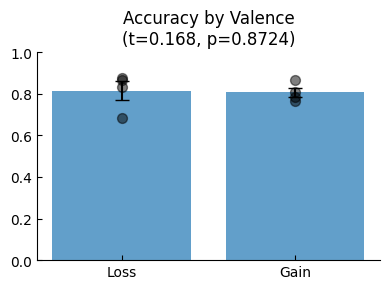

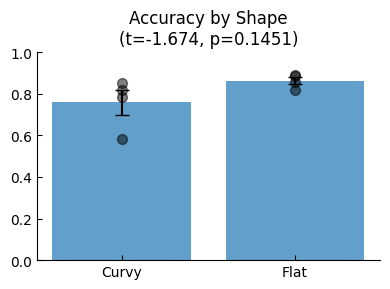

In [7]:
def plot_accuracy_bar_with_ttest(df, group_col, order=None, labels=None, title=None):
    
    # Get accuracy per subject per group
    subj_acc = df.groupby([group_col, 'subj'])['correct'].mean().reset_index()
    
    # Calculate group means and SEM
    acc_by_group = subj_acc.groupby(group_col)['correct'].agg(['mean', 'sem']).reindex(order)
    x_labels = [labels[v] if labels and v in labels else v for v in order]
    
    # T-test on subject means
    group_vals = [subj_acc[subj_acc[group_col] == g]['correct'].values for g in order]
    t_stat, p_val = stats.ttest_ind(group_vals[0], group_vals[1])
    
    # Plot bars with error bars
    plt.figure(figsize=(4, 3))
    x_pos = np.arange(len(order))
    plt.bar(x_pos, acc_by_group['mean'].values, yerr=acc_by_group['sem'].values, capsize=5, alpha=0.7)
    
    # Overlay subject points
    for i, g in enumerate(order):
        subj_vals = subj_acc[subj_acc[group_col] == g]['correct'].values
        plt.scatter([i] * len(subj_vals), subj_vals, alpha=0.5, s=50, color='black', zorder=3)
    
    plt.xticks(x_pos, x_labels)
    plt.title(f'{title}\n(t={t_stat:.3f}, p={p_val:.4f})')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
plot_accuracy_bar_with_ttest(df_subjs, 'valence', order=['pen', 'rew'], labels={'pen': 'Loss', 'rew': 'Gain'}, title='Accuracy by Valence')
plot_accuracy_bar_with_ttest(df_subjs, 'shape', order=['curv', 'flat'], labels={'curv': 'Curvy', 'flat': 'Flat'}, title='Accuracy by Shape')

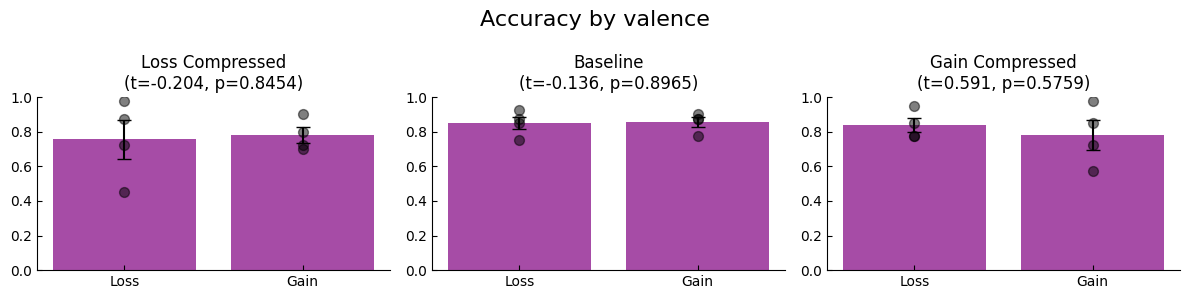

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for ax_idx, val_cond in enumerate(['pen_comp', 'baseline', 'rew_comp']):
    
    # Filter data for this valence_condition
    df_cond = df_subjs[df_subjs['valence_condition'] == val_cond]
    
    # Get accuracy per subject per valence
    subj_acc = df_cond.groupby(['valence', 'subj'])['correct'].mean().reset_index()
    
    # Calculate group means and SEM
    acc_by_valence = subj_acc.groupby('valence')['correct'].agg(['mean', 'sem']).reindex(['pen', 'rew'])
    x_labels = ['Loss', 'Gain']
    
    # T-test on subject means
    group_vals = [subj_acc[subj_acc['valence'] == v]['correct'].values for v in ['pen', 'rew']]
    t_stat, p_val = stats.ttest_ind(group_vals[0], group_vals[1])
    
    # Plot
    ax = axs[ax_idx]
    x_pos = np.arange(2)
    ax.bar(x_pos, acc_by_valence['mean'].values, yerr=acc_by_valence['sem'].values, capsize=5, alpha=0.7, color='purple')
    
    # Overlay subject points
    for i, v in enumerate(['pen', 'rew']):
        subj_vals = subj_acc[subj_acc['valence'] == v]['correct'].values
        ax.scatter([i] * len(subj_vals), subj_vals, alpha=0.5, s=50, color='black', zorder=3)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    
    # Set title with descriptive labels
    title_map = {'pen_comp': 'Loss Compressed', 'baseline': 'Baseline', 'rew_comp': 'Gain Compressed'}
    ax.set_title(f"{title_map[val_cond]}\n(t={t_stat:.3f}, p={p_val:.4f})")
    ax.set_ylim(0, 1)

plt.suptitle('Accuracy by valence', fontsize=16)
plt.tight_layout()
plt.show()

### Stim vs resp (valenced)

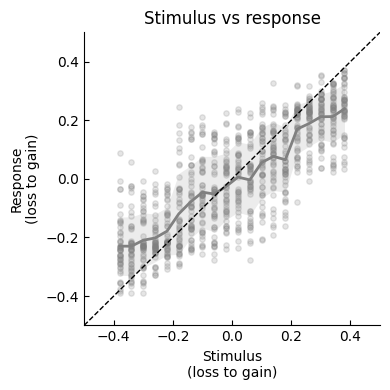

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

# Scatter all data points
ax.scatter(df_subjs['valence_stim'], df_subjs['valence_resp'], alpha=0.2, s=15, color='gray')

# Group by stimulus and get mean response with SD
grouped = df_subjs.groupby('valence_stim')['valence_resp']
mean_resp = grouped.mean().sort_index()
std_resp = grouped.std().sort_index()

x = mean_resp.index.values
y = mean_resp.values
yerr = std_resp.values

# Plot mean line
ax.plot(x, y, '-', linewidth=2, color='grey')
# Plot SD band
ax.fill_between(x, y - yerr, y + yerr, color='grey', alpha=0.15, linewidth=0)

# Diagonal reference
ax.plot([-0.5, 0.5], [-0.5, 0.5], 'k--', linewidth=1)
ax.set(title='Stimulus vs response',
       xlabel='Stimulus\n(loss to gain)', ylabel='Response\n(loss to gain)',
       xlim=(-0.5, 0.5), ylim=(-0.5, 0.5),
       xticks=[-0.4, -0.2, 0, 0.2, 0.4],
       yticks=[-0.4, -0.2, 0, 0.2, 0.4])
plt.tight_layout()
plt.show()

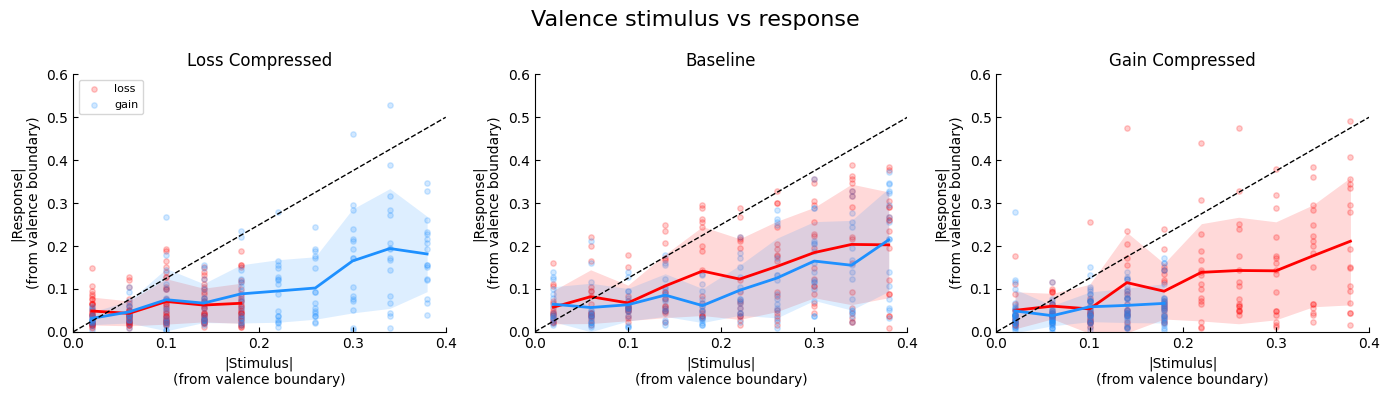

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, val_cond in enumerate(['pen_comp', 'baseline', 'rew_comp']):
    
    # Filter data for this valence_condition
    df_cond = df_subjs[df_subjs['valence_condition'] == val_cond].copy()
    
    # Create two datasets: loss stims (below boundary), gain stims (above boundary)
    df_loss = df_cond[df_cond['valence_stim'] < df_cond['valence_boundary']].copy()
    df_gain = df_cond[df_cond['valence_stim'] > df_cond['valence_boundary']].copy()
    
    # Distance from boundary
    df_loss['abs_stim'] = np.abs(df_loss['valence_stim'] - df_loss['valence_boundary'])
    df_loss['abs_resp'] = np.abs(df_loss['valence_resp'] - df_loss['valence_boundary'])
    df_gain['abs_stim'] = np.abs(df_gain['valence_stim'] - df_gain['valence_boundary'])
    df_gain['abs_resp'] = np.abs(df_gain['valence_resp'] - df_gain['valence_boundary'])
    
    # Scatter both
    ax = axs[ax_idx]
    ax.scatter(df_loss['abs_stim'], df_loss['abs_resp'], alpha=0.2, s=15, color='red', label='loss')
    ax.scatter(df_gain['abs_stim'], df_gain['abs_resp'], alpha=0.2, s=15, color='dodgerblue', label='gain')
    
    # Plot mean lines with SD bands for each
    for df_data, color in [(df_loss, 'red'), (df_gain, 'dodgerblue')]:
        grouped = df_data.groupby('abs_stim')['abs_resp']
        mean_resp = grouped.mean().sort_index()
        std_resp = grouped.std().sort_index()
        x = mean_resp.index.values
        y = mean_resp.values
        yerr = std_resp.values
        ax.plot(x, y, '-', linewidth=2, color=color)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15, linewidth=0)
    
    # Diagonal reference
    ax.plot([0, 0.4], [0, 0.5], 'k--', linewidth=1)
    
    # Title mapping
    title_map = {'pen_comp': 'Loss Compressed', 'baseline': 'Baseline', 'rew_comp': 'Gain Compressed'}
    ax.set_title(title_map[val_cond])
    ax.set(xlabel='|Stimulus|\n(from valence boundary)', ylabel='|Response|\n(from valence boundary)',
           xlim=(0, 0.4), ylim=(0, 0.6),
           xticks=[0, 0.1, 0.2, 0.3, 0.4],
           yticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ax_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Valence stimulus vs response', fontsize=16)
plt.tight_layout()
plt.show()

## Reaction times...

In [11]:
# Extract RT from slider response (in string format, often multiple elements)
import ast

def extract_rt(x):
    if pd.isna(x):
        return None
    try:
        if isinstance(x, str):
            lst = ast.literal_eval(x)
            return lst[0] if isinstance(lst, list) and len(lst) > 0 else lst if not isinstance(lst, list) else None
        elif isinstance(x, list):
            return x[0] if len(x) > 0 else None
        else:
            return x
    except:
        return None

df_subjs['RT'] = df_subjs['slider_resp.rt'].apply(extract_rt)

# Extract marker_init (initial position) and chosen_pos (final position) from positions list
def extract_positions(positions_str):
    if pd.isna(positions_str):
        return None, None
    try:
        positions = ast.literal_eval(positions_str) if isinstance(positions_str, str) else positions_str
        if isinstance(positions, list) and len(positions) > 0:
            return positions[0], positions[-1]  # initial, final
        return None, None
    except:
        return None, None

marker_init, chosen_pos = zip(*df_subjs['positions'].apply(extract_positions))
df_subjs['marker_init'] = marker_init
df_subjs['chosen_pos'] = chosen_pos

# Calculate distance moved from marker_init to target_stim
df_subjs['dist_moved'] = (df_subjs['target_stim'] - df_subjs['marker_init']).abs()

# Compute normalized RT: RT / (10 * (distance_moved + 0.01))
df_subjs['normed_RT'] = df_subjs['RT'] / (10 * (df_subjs['dist_moved'] + 0.01))

print(f"RT extracted for {df_subjs['RT'].notna().sum()} trials")
print(f"Distance moved calculated for {df_subjs['dist_moved'].notna().sum()} trials")
print(f"Normed RT calculated for {df_subjs['normed_RT'].notna().sum()} trials")


RT extracted for 947 trials
Distance moved calculated for 960 trials
Normed RT calculated for 947 trials


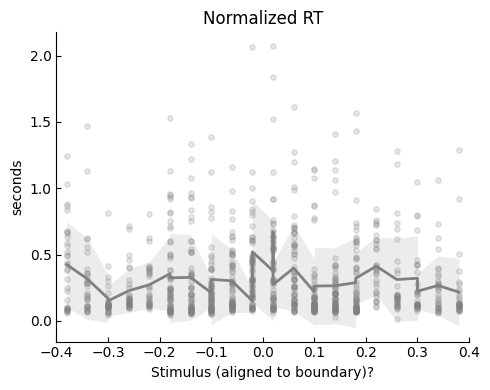

In [12]:
# Normalized RT by stimulus valence (aligned to boundary)
fig, ax = plt.subplots(figsize=(5, 4))

# Scatter all data points
ax.scatter(df_subjs['valence_stim_aligned'], df_subjs['normed_RT'], alpha=0.2, s=15, color='gray')

# Group by aligned stimulus and get mean normalized RT with SD
grouped = df_subjs.groupby('valence_stim_aligned')['normed_RT']
mean_rt = grouped.mean().sort_index()
std_rt = grouped.std().sort_index()

x = mean_rt.index.values
y = mean_rt.values
yerr = std_rt.values

# Plot mean line
ax.plot(x, y, '-', linewidth=2, color='grey')
# Plot SD band
ax.fill_between(x, y - yerr, y + yerr, color='grey', alpha=0.15, linewidth=0)

ax.set(title='Normalized RT',
       xlabel='Stimulus (aligned to boundary)?', ylabel='seconds', xlim=(-0.4, 0.4))
plt.tight_layout()
plt.show()

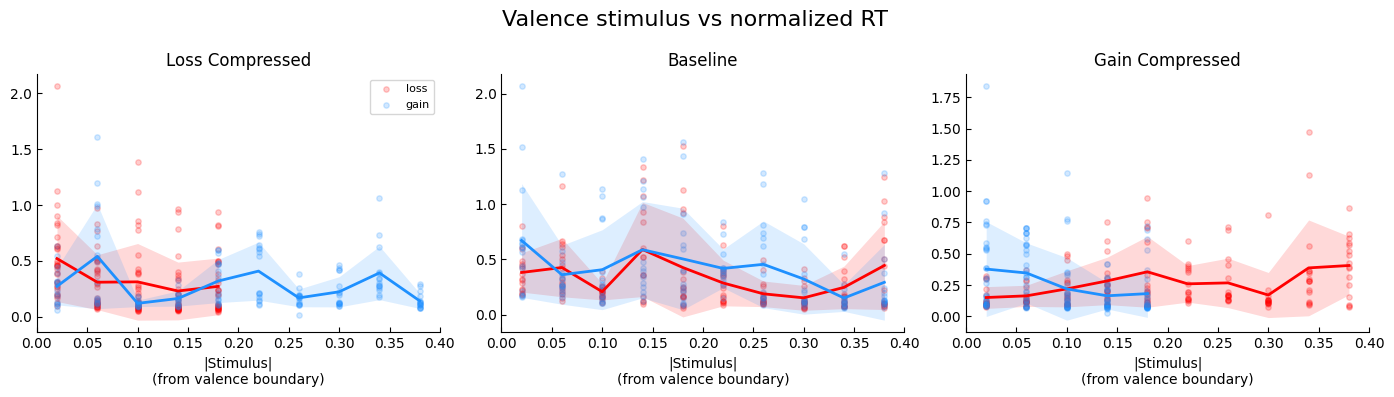

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, val_cond in enumerate(['pen_comp', 'baseline', 'rew_comp']):
    
    # Filter data for this valence_condition
    df_cond = df_subjs[df_subjs['valence_condition'] == val_cond].copy()
    
    # Create two datasets: loss stims (below boundary), gain stims (above boundary)
    df_loss = df_cond[df_cond['valence_stim'] < df_cond['valence_boundary']].copy()
    df_gain = df_cond[df_cond['valence_stim'] > df_cond['valence_boundary']].copy()
    
    # Distance from boundary
    df_loss['abs_stim'] = np.abs(df_loss['valence_stim'] - df_loss['valence_boundary'])
    df_gain['abs_stim'] = np.abs(df_gain['valence_stim'] - df_gain['valence_boundary'])
    
    # Scatter both
    ax = axs[ax_idx]
    ax.scatter(df_loss['abs_stim'], df_loss['normed_RT'], alpha=0.2, s=15, color='red', label='loss')
    ax.scatter(df_gain['abs_stim'], df_gain['normed_RT'], alpha=0.2, s=15, color='dodgerblue', label='gain')
    
    # Plot mean lines with SD bands for each
    for df_data, color in [(df_loss, 'red'), (df_gain, 'dodgerblue')]:
        grouped = df_data.groupby('abs_stim')['normed_RT']
        mean_rt = grouped.mean().sort_index()
        std_rt = grouped.std().sort_index()
        x = mean_rt.index.values
        y = mean_rt.values
        yerr = std_rt.values
        ax.plot(x, y, '-', linewidth=2, color=color)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15, linewidth=0)
    
    # Title mapping
    title_map = {'pen_comp': 'Loss Compressed', 'baseline': 'Baseline', 'rew_comp': 'Gain Compressed'}
    ax.set_title(title_map[val_cond])
    ax.set(xlabel='|Stimulus|\n(from valence boundary)', xlim=(0, 0.4))
    if ax_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Valence stimulus vs normalized RT', fontsize=16)
plt.tight_layout()
plt.show()

### Psychometrics

In [14]:
# from scipy.optimize import curve_fit

# def logistic(x, L, x0, k):
#     """Logistic/sigmoid function"""
#     return L / (1 + np.exp(-k * (x - x0)))

# # Bin stimulus and calculate proportion of positive responses
# bins = np.linspace(df_subjs['valence_stim'].min(), df_subjs['valence_stim'].max(), 10)
# bin_centers = (bins[:-1] + bins[1:]) / 2
# binned = pd.cut(df_subjs['valence_stim'], bins=bins)

# # Proportion of positive (gain) responses per bin
# prop_pos = df_subjs.groupby(binned)['valence_resp'].apply(lambda x: (x > 0).mean())
# prop_x = bin_centers[~np.isnan(prop_pos.values)]
# prop_y = prop_pos.dropna().values

# # Fit logistic curve
# try:
#     popt, _ = curve_fit(logistic, prop_x, prop_y, p0=[1, 0, 1], maxfev=5000)
#     x_smooth = np.linspace(df_subjs['valence_stim'].min(), df_subjs['valence_stim'].max(), 100)
#     y_smooth = logistic(x_smooth, *popt)
#     has_fit = True
# except:
#     has_fit = False

# # Plot
# fig, ax = plt.subplots(figsize=(5, 4))
# ax.scatter(prop_x, prop_y, s=100, alpha=0.6, color='dodgerblue', zorder=3)
# if has_fit:
#     ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Logistic fit')
# ax.axhline(0.5, linestyle='--', color='k', alpha=0.3)
# ax.axvline(0, linestyle='--', color='k', alpha=0.3)
# ax.set(xlabel='Stimulus Valence (loss → gain)', ylabel='Proportion Positive Responses',
#        ylim=(-0.05, 1.05), title='Psychometric Curve (All Data)')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [15]:
# fig, axs = plt.subplots(1, 3, figsize=(14, 4))

# for ax_idx, val_cond in enumerate(['pen_comp', 'baseline', 'rew_comp']):
    
#     # Filter data for this valence_condition
#     df_cond = df_subjs[df_subjs['valence_condition'] == val_cond].copy()
    
#     # Bin stimulus and calculate proportion of positive responses
#     bins = np.linspace(df_cond['valence_stim'].min(), df_cond['valence_stim'].max(), 8)
#     bin_centers = (bins[:-1] + bins[1:]) / 2
#     binned = pd.cut(df_cond['valence_stim'], bins=bins)
    
#     # Proportion of positive responses per bin
#     prop_pos = df_cond.groupby(binned)['valence_resp'].apply(lambda x: (x > 0).mean())
#     prop_x = bin_centers[~np.isnan(prop_pos.values)]
#     prop_y = prop_pos.dropna().values
    
#     # Fit logistic curve
#     try:
#         popt, _ = curve_fit(logistic, prop_x, prop_y, p0=[1, 0, 1], maxfev=5000)
#         x_smooth = np.linspace(df_cond['valence_stim'].min(), df_cond['valence_stim'].max(), 100)
#         y_smooth = logistic(x_smooth, *popt)
#         has_fit = True
#     except:
#         has_fit = False
    
#     # Plot
#     ax = axs[ax_idx]
#     ax.scatter(prop_x, prop_y, s=100, alpha=0.6, color='dodgerblue', zorder=3)
#     if has_fit:
#         ax.plot(x_smooth, y_smooth, 'r-', linewidth=2)
#     ax.axhline(0.5, linestyle='--', color='k', alpha=0.3)
#     ax.axvline(0, linestyle='--', color='k', alpha=0.3)
    
#     title_map = {'pen_comp': 'Loss Compressed', 'baseline': 'Baseline', 'rew_comp': 'Gain Compressed'}
#     ax.set(xlabel='Stimulus Valence', ylabel='Proportion Positive',
#            ylim=(-0.05, 1.05), title=title_map[val_cond])

# plt.tight_layout()
# plt.show()